# LIME Explanations for the Frozen Credit-Risk Model

This notebook applies LIME to the same frozen XGBoost model, preprocessing pipeline, held-out rows, and fixed XAI cases used by the SHAP stage. It is an explanation stage only: neither the model nor preprocessor is fitted or modified.

In [13]:
import json
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score

RANDOM_STATE = 42
NUM_SAMPLES = 5000
NUM_FEATURES = 5
TARGET = "TARGET"
LIME_VERSION = version("lime")
print(f"LIME version: {LIME_VERSION}")

LIME version: 0.2.0.1


## 1–2. Load and Reconstruct the Frozen Experiment

In [14]:
ARTIFACTS_DIR = Path("../artifacts")
DATA_PATH = Path("../data/raw/application_train.csv")
MODEL_PATH = ARTIFACTS_DIR / "xgboost_credit_model.joblib"
PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor.joblib"
MODEL_METADATA_PATH = ARTIFACTS_DIR / "model_metadata.json"
TRAIN_INDICES_PATH = ARTIFACTS_DIR / "train_indices.csv"
TEST_INDICES_PATH = ARTIFACTS_DIR / "test_indices.csv"
PREPROCESSING_METADATA_PATH = ARTIFACTS_DIR / "preprocessing_metadata.csv"
PRIMARY_FEATURES_PATH = ARTIFACTS_DIR / "primary_features.json"
XAI_CASES_PATH = ARTIFACTS_DIR / "xai_evaluation_cases.csv"

model = joblib.load(MODEL_PATH)
preprocessor = joblib.load(PREPROCESSOR_PATH)
with MODEL_METADATA_PATH.open(encoding="utf-8") as file:
    model_metadata = json.load(file)
with PRIMARY_FEATURES_PATH.open(encoding="utf-8") as file:
    modelling_feature_names = json.load(file)
preprocessing_metadata = pd.read_csv(PREPROCESSING_METADATA_PATH)
train_indices = pd.read_csv(TRAIN_INDICES_PATH)["row_index"].astype(int)
test_indices = pd.read_csv(TEST_INDICES_PATH)["row_index"].astype(int)
xai_cases = pd.read_csv(XAI_CASES_PATH)
decision_threshold = float(model_metadata["decision_threshold"])
assert hasattr(model, "classes_")

ORIGINAL_FEATURES = [
    "NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "AMT_CREDIT",
    "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_EMPLOYED",
    "NAME_INCOME_TYPE", "NAME_HOUSING_TYPE", "CNT_FAM_MEMBERS",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
]
raw_df = pd.read_csv(DATA_PATH)
modelling_df = raw_df[ORIGINAL_FEATURES + [TARGET]].copy()
employment_days = modelling_df["DAYS_EMPLOYED"].mask(modelling_df["DAYS_EMPLOYED"].eq(365243), np.nan)
modelling_df["EMPLOYMENT_YEARS"] = employment_days.abs().div(365.25)
modelling_df.drop(columns=["DAYS_EMPLOYED"], inplace=True)

def safe_ratio(numerator, denominator):
    return numerator.div(denominator.mask(denominator.eq(0), np.nan))

def recalculate_ratios(frame):
    frame = frame.copy()
    frame["CREDIT_INCOME_RATIO"] = safe_ratio(frame["AMT_CREDIT"], frame["AMT_INCOME_TOTAL"])
    frame["ANNUITY_INCOME_RATIO"] = safe_ratio(frame["AMT_ANNUITY"], frame["AMT_INCOME_TOTAL"])
    frame["CREDIT_ANNUITY_RATIO"] = safe_ratio(frame["AMT_CREDIT"], frame["AMT_ANNUITY"])
    return frame.replace([np.inf, -np.inf], np.nan)

modelling_df = recalculate_ratios(modelling_df)
assert modelling_df.columns.drop(TARGET).tolist() == modelling_feature_names
X_train_raw = modelling_df.loc[train_indices, modelling_feature_names].copy()
X_test_raw = modelling_df.loc[test_indices, modelling_feature_names].copy()
y_test = modelling_df.loc[test_indices, TARGET].copy()
X_test_processed = preprocessor.transform(X_test_raw)
frozen_probabilities = model.predict_proba(X_test_processed)[:, 1]
frozen_predictions = (frozen_probabilities >= decision_threshold).astype(int)
reproduced = {
    "roc_auc": roc_auc_score(y_test, frozen_probabilities),
    "pr_auc": average_precision_score(y_test, frozen_probabilities),
    "precision_positive": precision_score(y_test, frozen_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, frozen_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, frozen_predictions, zero_division=0),
}
print(f"Exact held-out rows: {len(X_test_raw)}")
print(f"Processed test shape: {X_test_processed.shape}")
for name, value in reproduced.items():
    print(f"Reproduced {name}: {value:.6f}")
    assert np.isclose(value, float(model_metadata[name]), atol=1e-6)

Exact held-out rows: 61503
Processed test shape: (61503, 28)
Reproduced roc_auc: 0.692518
Reproduced pr_auc: 0.167144
Reproduced precision_positive: 0.138796
Reproduced recall_positive: 0.621551
Reproduced f1_positive: 0.226920


## 3. Reuse the Exact 20 Fixed XAI Cases

In [15]:
required_case_columns = ["case_id", "row_index", "true_target", "predicted_class", "predicted_probability", "case_type"]
assert xai_cases.columns.tolist() == required_case_columns
assert len(xai_cases) == 20 and xai_cases["case_id"].is_unique
assert xai_cases["row_index"].isin(test_indices).all()
test_position_by_index = pd.Series(np.arange(len(test_indices)), index=test_indices.to_numpy())
case_test_positions = test_position_by_index.loc[xai_cases["row_index"]].to_numpy()
assert np.allclose(frozen_probabilities[case_test_positions], xai_cases["predicted_probability"], atol=1e-6)
display(xai_cases)

,case_id,row_index,true_target,predicted_class,predicted_probability,case_type
0,XAI_001,288644,0,1,0.871334,high-confidence positive
1,XAI_002,234361,0,1,0.861796,high-confidence positive
2,XAI_003,25106,1,1,0.851671,high-confidence positive
3,XAI_004,148440,0,1,0.845883,high-confidence positive
4,XAI_005,267529,0,1,0.844541,high-confidence positive
5,XAI_006,259190,0,1,0.500000,borderline positive
6,XAI_007,125832,0,1,0.500008,borderline positive
7,XAI_008,3508,0,1,0.500023,borderline positive
8,XAI_009,264908,0,1,0.500030,borderline positive
9,XAI_010,253960,0,1,0.500040,borderline positive


## 4–6. Human-Readable LIME Representation and Safe Prediction Wrapper

LIME operates on the same 15 pre-encoding modelling features. Categorical mappings and numerical reference values are learned from the saved training partition only, without using `TARGET`. Integer category codes exist only inside LIME; final displays restore the original category strings.

In [16]:
CATEGORICAL_FEATURES = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()
NUMERIC_FEATURES = X_train_raw.select_dtypes(include=np.number).columns.tolist()
categorical_indexes = [modelling_feature_names.index(feature) for feature in CATEGORICAL_FEATURES]
numeric_training_medians = X_train_raw[NUMERIC_FEATURES].median()
categorical_training_modes = X_train_raw[CATEGORICAL_FEATURES].mode(dropna=True).iloc[0]
category_values = {
    feature: sorted(X_train_raw[feature].dropna().astype(str).unique().tolist())
    for feature in CATEGORICAL_FEATURES
}
category_to_code = {feature: {value: code for code, value in enumerate(values)} for feature, values in category_values.items()}
categorical_names = {modelling_feature_names.index(feature): values for feature, values in category_values.items()}

def encode_for_lime(frame):
    encoded = frame[modelling_feature_names].copy()
    encoded[NUMERIC_FEATURES] = encoded[NUMERIC_FEATURES].fillna(numeric_training_medians)
    for feature in CATEGORICAL_FEATURES:
        values = encoded[feature].fillna(categorical_training_modes[feature]).astype(str)
        encoded[feature] = values.map(category_to_code[feature]).astype(float)
    return encoded.astype(float)

def decode_lime_samples(samples):
    sample_array = np.atleast_2d(np.asarray(samples, dtype=float))
    decoded = pd.DataFrame(sample_array, columns=modelling_feature_names)
    for feature in CATEGORICAL_FEATURES:
        values = category_values[feature]
        codes = np.rint(decoded[feature]).astype(int).clip(0, len(values) - 1)
        decoded[feature] = [values[code] for code in codes]
    return decoded

def lime_predict_proba(samples):
    decoded = decode_lime_samples(samples)
    processed = preprocessor.transform(decoded)
    return model.predict_proba(processed)

lime_train = encode_for_lime(X_train_raw)
lime_test = encode_for_lime(X_test_raw)
wrapper_check_positions = np.arange(5)
wrapper_probabilities = lime_predict_proba(lime_test.iloc[wrapper_check_positions].to_numpy())[:, 1]
max_wrapper_difference = float(np.max(np.abs(wrapper_probabilities - frozen_probabilities[wrapper_check_positions])))
print(f"Maximum wrapper probability difference: {max_wrapper_difference:.12g}")
assert np.allclose(wrapper_probabilities, frozen_probabilities[wrapper_check_positions], atol=1e-7)

Maximum wrapper probability difference: 0


## 7. Build the LIME Explainer

In [17]:
DISPLAY_NAMES = {
    "NAME_CONTRACT_TYPE": "Contract type", "AMT_INCOME_TOTAL": "Annual income",
    "AMT_CREDIT": "Requested credit amount", "AMT_ANNUITY": "Annuity amount",
    "AMT_GOODS_PRICE": "Goods price", "CNT_FAM_MEMBERS": "Family members",
    "EMPLOYMENT_YEARS": "Employment duration", "NAME_INCOME_TYPE": "Income type",
    "NAME_HOUSING_TYPE": "Housing type", "CREDIT_INCOME_RATIO": "Credit-to-income ratio",
    "ANNUITY_INCOME_RATIO": "Annuity-to-income ratio", "CREDIT_ANNUITY_RATIO": "Credit-to-annuity ratio",
    "AMT_REQ_CREDIT_BUREAU_MON": "Credit enquiries in previous month",
    "AMT_REQ_CREDIT_BUREAU_QRT": "Credit enquiries in previous quarter",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "Credit enquiries in previous year",
}
CLASS_NAMES = ["Lower model risk", "Higher model risk"]

def make_explainer(seed=RANDOM_STATE):
    return LimeTabularExplainer(
        training_data=lime_train.to_numpy(), feature_names=modelling_feature_names,
        class_names=CLASS_NAMES, categorical_features=categorical_indexes,
        categorical_names=categorical_names, mode="classification",
        discretize_continuous=True, random_state=seed,
    )

print(f"Background rows (training only): {len(lime_train)}")
print(f"Categorical indexes: {categorical_indexes}")
print(f"num_samples: {NUM_SAMPLES}; num_features: {NUM_FEATURES}; random seed: {RANDOM_STATE}")

Background rows (training only): 246008
Categorical indexes: [0, 5, 6]
num_samples: 5000; num_features: 5; random seed: 42


## 8–10. Generate and Save Local LIME Explanations

Each case uses the same settings and a freshly seeded explainer, making the perturbation policy deterministic across manual reruns. Weights describe the local surrogate for the higher-risk probability and are not causal effects.

In [18]:
def identify_original_feature(rule):
    matches = [feature for feature in modelling_feature_names if feature in rule]
    if not matches:
        raise ValueError(f"Could not map LIME rule to an original feature: {rule}")
    return max(matches, key=len)

def readable_rule(rule, original_feature, raw_value):
    display_name = DISPLAY_NAMES[original_feature]
    if original_feature in CATEGORICAL_FEATURES:
        return f"{display_name}: {raw_value}"
    readable = rule.replace(original_feature, display_name)
    if original_feature == "EMPLOYMENT_YEARS":
        readable += " years"
    return readable

local_records = []
for case in xai_cases.itertuples(index=False):
    test_position = int(test_position_by_index.loc[case.row_index])
    encoded_row = lime_test.iloc[test_position].to_numpy()
    explanation = make_explainer().explain_instance(
        encoded_row, lime_predict_proba, labels=[1],
        num_features=NUM_FEATURES, num_samples=NUM_SAMPLES,
    )
    raw_row = X_test_raw.loc[case.row_index]
    for rank, (rule, weight) in enumerate(explanation.as_list(label=1), start=1):
        original_feature = identify_original_feature(rule)
        raw_value = raw_row[original_feature]
        local_records.append({
            "case_id": case.case_id, "row_index": int(case.row_index),
            "true_target": int(case.true_target), "predicted_class": int(case.predicted_class),
            "predicted_probability": float(case.predicted_probability),
            "lime_local_prediction": float(np.asarray(explanation.local_pred).reshape(-1)[0]),
            "lime_intercept": float(explanation.intercept[1]), "local_fidelity_r2": float(explanation.score),
            "feature_rule": rule, "original_feature": original_feature,
            "display_feature": DISPLAY_NAMES[original_feature],
            "display_rule": readable_rule(rule, original_feature, raw_value),
            "display_value": raw_value, "lime_weight": float(weight),
            "direction": "increases local higher-risk prediction" if weight > 0 else "decreases local higher-risk prediction",
            "rank": rank,
        })

lime_local_explanations = pd.DataFrame(local_records).sort_values(["case_id", "rank"]).reset_index(drop=True)
lime_top_factors = lime_local_explanations.copy()
LIME_LOCAL_PATH = ARTIFACTS_DIR / "lime_local_explanations.csv"
LIME_TOP_FACTORS_PATH = ARTIFACTS_DIR / "lime_top_factors.csv"
lime_local_explanations.to_csv(LIME_LOCAL_PATH, index=False)
lime_top_factors.to_csv(LIME_TOP_FACTORS_PATH, index=False)
display(lime_top_factors)

,case_id,row_index,true_target,predicted_class,predicted_probability,lime_local_prediction,lime_intercept,local_fidelity_r2,feature_rule,original_feature,display_feature,display_rule,display_value,lime_weight,direction,rank
0,XAI_001,288644,0,1,0.871334,0.587617,0.245082,0.237285,NAME_CONTRACT_TYPE=Cash loans,NAME_CONTRACT_TYPE,Contract type,Contract type: Cash loans,Cash loans,0.159921,increases local higher-risk prediction,1
1,XAI_001,288644,0,1,0.871334,0.587617,0.245082,0.237285,238500.00 < AMT_GOODS_PRICE <= 450000.00,AMT_GOODS_PRICE,Goods price,238500.00 < Goods price <= 450000.00,436500.0,0.093593,increases local higher-risk prediction,2
2,XAI_001,288644,0,1,0.871334,0.587617,0.245082,0.237285,EMPLOYMENT_YEARS <= 2.55,EMPLOYMENT_YEARS,Employment duration,Employment duration <= 2.55 years,1.46475,0.070489,increases local higher-risk prediction,3
3,XAI_001,288644,0,1,0.871334,0.587617,0.245082,0.237285,NAME_INCOME_TYPE=Working,NAME_INCOME_TYPE,Income type,Income type: Working,Working,0.043137,increases local higher-risk prediction,4
4,XAI_001,288644,0,1,0.871334,0.587617,0.245082,0.237285,AMT_REQ_CREDIT_BUREAU_YEAR <= 1.00,AMT_REQ_CREDIT_BUREAU_YEAR,Credit enquiries in previous year,Credit enquiries in previous year <= 1.00,0.0,-0.024605,decreases local higher-risk prediction,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,XAI_020,200211,0,0,0.499947,0.393377,0.403408,0.258771,NAME_CONTRACT_TYPE=Revolving loans,NAME_CONTRACT_TYPE,Contract type,Contract type: Revolving loans,Revolving loans,-0.162205,decreases local higher-risk prediction,1
96,XAI_020,200211,0,0,0.499947,0.393377,0.403408,0.258771,238500.00 < AMT_GOODS_PRICE <= 450000.00,AMT_GOODS_PRICE,Goods price,238500.00 < Goods price <= 450000.00,247500.0,0.092211,increases local higher-risk prediction,2
97,XAI_020,200211,0,0,0.499947,0.393377,0.403408,0.258771,EMPLOYMENT_YEARS <= 2.55,EMPLOYMENT_YEARS,Employment duration,Employment duration <= 2.55 years,1.256674,0.070082,increases local higher-risk prediction,3
98,XAI_020,200211,0,0,0.499947,0.393377,0.403408,0.258771,AMT_ANNUITY <= 16510.50,AMT_ANNUITY,Annuity amount,Annuity amount <= 16510.50,12375.0,-0.053514,decreases local higher-risk prediction,4


## 11. Deterministic Rule-Based Plain-English Explanations

In [19]:
def plain_english_summary(factors):
    factors = factors.sort_values("rank").head(NUM_FEATURES)
    names = factors["display_feature"].str.lower().tolist()
    introduction = "The local LIME explanation identified " + ", ".join(names[:-1]) + f" and {names[-1]} as important factors in this local approximation. "
    effects = [f"{row.display_feature} {('increased' if row.lime_weight > 0 else 'reduced')} the local higher-risk prediction" for row in factors.itertuples()]
    return introduction + "; ".join(effects) + "."

lime_plain_english = xai_cases[["case_id", "predicted_probability", "predicted_class"]].copy()
summaries = lime_top_factors.groupby("case_id", sort=False).apply(plain_english_summary, include_groups=False)
lime_plain_english["plain_english_explanation"] = lime_plain_english["case_id"].map(summaries)
LIME_PLAIN_ENGLISH_PATH = ARTIFACTS_DIR / "lime_plain_english.csv"
lime_plain_english.to_csv(LIME_PLAIN_ENGLISH_PATH, index=False)
display(lime_plain_english)

,case_id,predicted_probability,predicted_class,plain_english_explanation
0,XAI_001,0.871334,1,The local LIME explanation identified contract...
1,XAI_002,0.861796,1,The local LIME explanation identified contract...
2,XAI_003,0.851671,1,The local LIME explanation identified contract...
3,XAI_004,0.845883,1,The local LIME explanation identified contract...
4,XAI_005,0.844541,1,The local LIME explanation identified contract...
5,XAI_006,0.500000,1,The local LIME explanation identified contract...
6,XAI_007,0.500008,1,The local LIME explanation identified contract...
7,XAI_008,0.500023,1,The local LIME explanation identified contract...
8,XAI_009,0.500030,1,The local LIME explanation identified goods pr...
9,XAI_010,0.500040,1,The local LIME explanation identified goods pr...


## 12. Representative LIME Visualisation — XAI_005

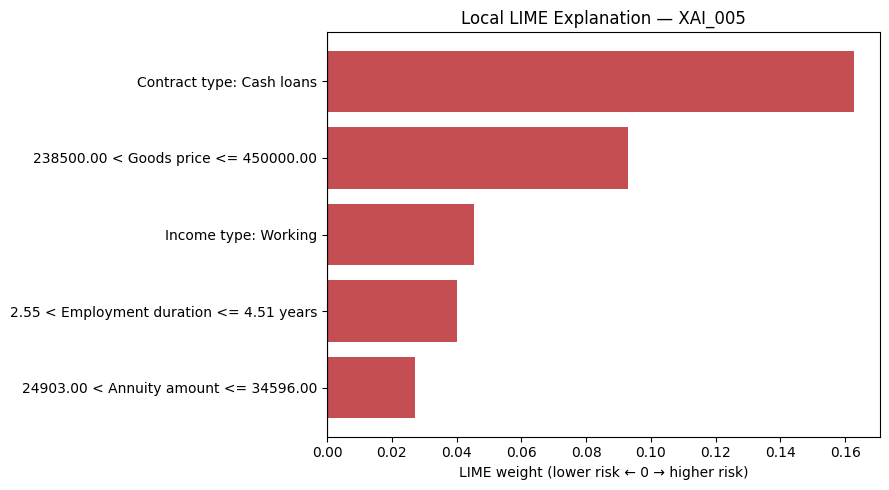

In [20]:
representative_factors = lime_top_factors.loc[lime_top_factors["case_id"].eq("XAI_005")].sort_values("lime_weight")
colours = np.where(representative_factors["lime_weight"] >= 0, "#C44E52", "#2A7D4F")
plt.figure(figsize=(9, 5))
plt.barh(representative_factors["display_rule"], representative_factors["lime_weight"], color=colours)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("LIME weight (lower risk ← 0 → higher risk)")
plt.title("Local LIME Explanation — XAI_005")
plt.tight_layout()
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LIME_PLOT_PATH = PLOTS_DIR / "lime_representative_explanation.png"
plt.savefig(LIME_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()

## 13. LIME Sparsity and Complexity Preparation

LIME reports only the configured top five features here. Consequently, these complexity counts are constrained by `num_features=5` and are not directly equivalent to SHAP's non-zero attribution count.

In [21]:
def count_for_fraction(weights, fraction):
    ordered = np.sort(np.abs(weights))[::-1]
    return 0 if ordered.sum() == 0 else int(np.searchsorted(np.cumsum(ordered), fraction * ordered.sum()) + 1)

sparsity_records = []
for case_id, factors in lime_top_factors.groupby("case_id", sort=False):
    weights = factors["lime_weight"].to_numpy()
    sparsity_records.append({
        "case_id": case_id, "number_of_reported_features": len(weights),
        "absolute_weight_sum": float(np.abs(weights).sum()),
        "features_for_50_percent": count_for_fraction(weights, 0.50),
        "features_for_80_percent": count_for_fraction(weights, 0.80),
    })
lime_sparsity_metrics = pd.DataFrame(sparsity_records)
LIME_SPARSITY_PATH = ARTIFACTS_DIR / "lime_sparsity_metrics.csv"
lime_sparsity_metrics.to_csv(LIME_SPARSITY_PATH, index=False)
display(lime_sparsity_metrics)

,case_id,number_of_reported_features,absolute_weight_sum,features_for_50_percent,features_for_80_percent
0,XAI_001,5,0.391745,2,3
1,XAI_002,5,0.393911,2,3
2,XAI_003,5,0.391647,2,3
3,XAI_004,5,0.394117,2,3
4,XAI_005,5,0.368157,2,3
5,XAI_006,5,0.421330,2,3
6,XAI_007,5,0.291859,1,3
7,XAI_008,5,0.453448,2,4
8,XAI_009,5,0.498309,2,3
9,XAI_010,5,0.474811,2,3


## 14–15. Preliminary Stability and Faithfulness Checks

LIME is stochastic. These five-case tests are limited sanity checks, not evidence of general stability or causality. Fresh explainers use the same seed for reproducibility. Masking references are calculated from training data only.

### Preliminary LIME Faithfulness Diagnostic

The top-ranked feature comes from LIME's local surrogate. Replacing it with its existing value is not a valid intervention, so categorical replacements use a different valid training-set category and numerical replacements use a different training-set median or quartile. Derived ratios are changed only through a valid underlying feature and then recomputed consistently. The resulting probability change is a preliminary model-behaviour sanity check, not causal evidence; formal cross-method faithfulness evaluation is deferred.

In [22]:
def explain_encoded_row(encoded_row):
    return make_explainer().explain_instance(encoded_row, lime_predict_proba, labels=[1], num_features=NUM_FEATURES, num_samples=NUM_SAMPLES)

stability_records = []
faithfulness_records = []
DERIVED_UNDERLYING_FEATURE = {
    "CREDIT_INCOME_RATIO": "AMT_CREDIT",
    "ANNUITY_INCOME_RATIO": "AMT_ANNUITY",
    "CREDIT_ANNUITY_RATIO": "AMT_CREDIT",
}

def values_differ(original, replacement):
    if pd.isna(original) and pd.isna(replacement):
        return False
    if isinstance(original, (int, float, np.integer, np.floating)) and isinstance(replacement, (int, float, np.integer, np.floating)):
        return not np.isclose(float(original), float(replacement), rtol=1e-9, atol=1e-12, equal_nan=True)
    return str(original) != str(replacement)

def numerical_replacement(feature, original):
    training_values = X_train_raw[feature].replace([np.inf, -np.inf], np.nan).dropna()
    candidates = [training_values.median(), training_values.quantile(0.25), training_values.quantile(0.75)]
    return next((float(value) for value in candidates if np.isfinite(value) and values_differ(original, value)), None)

def categorical_replacement(feature, original):
    frequencies = X_train_raw[feature].dropna().value_counts()
    return next((value for value in frequencies.index if values_differ(original, value)), None)
continuous_candidates = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "EMPLOYMENT_YEARS"]
for case in xai_cases.head(5).itertuples(index=False):
    position = int(test_position_by_index.loc[case.row_index])
    original_raw = X_test_raw.loc[[case.row_index]].copy()
    original_rules = lime_top_factors.loc[lime_top_factors["case_id"].eq(case.case_id), "original_feature"].tolist()
    perturb_feature = next(feature for feature in continuous_candidates if pd.notna(original_raw.iloc[0][feature]))
    perturbed_raw = original_raw.copy()
    perturbed_raw[perturb_feature] *= 1.01
    perturbed_raw = recalculate_ratios(perturbed_raw)
    perturbed_explanation = explain_encoded_row(encode_for_lime(perturbed_raw).iloc[0].to_numpy())
    perturbed_features = [identify_original_feature(rule) for rule, _ in perturbed_explanation.as_list(label=1)]
    stability_records.append({"case_id": case.case_id, "perturbed_feature": perturb_feature, "top_5_overlap_count": len(set(original_rules).intersection(perturbed_features))})

    top_feature = original_rules[0]
    intervened_feature = DERIVED_UNDERLYING_FEATURE.get(top_feature, top_feature)
    original_value = original_raw.iloc[0][intervened_feature]
    if intervened_feature in CATEGORICAL_FEATURES:
        replacement = categorical_replacement(intervened_feature, original_value)
    else:
        replacement = numerical_replacement(intervened_feature, original_value)

    feature_actually_changed = replacement is not None and values_differ(original_value, replacement)
    if replacement is None:
        status = "skipped - no alternative value"
        masked_probability = np.nan
        absolute_score_change = np.nan
    elif top_feature in DERIVED_UNDERLYING_FEATURE and intervened_feature not in X_train_raw.columns:
        status = "skipped - derived feature"
        masked_probability = np.nan
        absolute_score_change = np.nan
    else:
        assert feature_actually_changed
        intervened_raw = original_raw.copy()
        intervened_raw[intervened_feature] = replacement
        if intervened_feature in {"AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"}:
            intervened_raw = recalculate_ratios(intervened_raw)
        masked_probability = float(model.predict_proba(preprocessor.transform(intervened_raw))[:, 1][0])
        absolute_score_change = abs(float(case.predicted_probability) - masked_probability)
        status = "valid intervention"

    faithfulness_records.append({
        "case_id": case.case_id, "top_lime_feature": top_feature,
        "intervened_feature": intervened_feature,
        "original_feature_value": original_value, "replacement_value": replacement,
        "feature_actually_changed": bool(feature_actually_changed),
        "faithfulness_test_status": status,
        "original_probability": float(case.predicted_probability),
        "masked_probability": masked_probability, "absolute_score_change": absolute_score_change,
    })

lime_preliminary_stability = pd.DataFrame(stability_records)
lime_preliminary_faithfulness = pd.DataFrame(faithfulness_records)
LIME_STABILITY_PATH = ARTIFACTS_DIR / "lime_preliminary_stability.csv"
LIME_FAITHFULNESS_PATH = ARTIFACTS_DIR / "lime_preliminary_faithfulness.csv"
lime_preliminary_faithfulness.to_csv(LIME_FAITHFULNESS_PATH, index=False)

repeat_row = lime_test.iloc[int(test_position_by_index.loc[xai_cases.iloc[0]["row_index"]])].to_numpy()
repeat_a = make_explainer().explain_instance(repeat_row, lime_predict_proba, labels=[1], num_features=NUM_FEATURES, num_samples=NUM_SAMPLES).as_list(label=1)
repeat_b = make_explainer().explain_instance(repeat_row, lime_predict_proba, labels=[1], num_features=NUM_FEATURES, num_samples=NUM_SAMPLES).as_list(label=1)
same_seed_reproducible = repeat_a == repeat_b
print(f"Same-seed explanation reproduced exactly: {same_seed_reproducible}")
display(lime_preliminary_stability)
display(lime_preliminary_faithfulness)
assert lime_preliminary_faithfulness.loc[
    lime_preliminary_faithfulness["faithfulness_test_status"].eq("valid intervention"),
    "feature_actually_changed",
].all()

Same-seed explanation reproduced exactly: True


,case_id,perturbed_feature,top_5_overlap_count
0,XAI_001,AMT_INCOME_TOTAL,5
1,XAI_002,AMT_INCOME_TOTAL,5
2,XAI_003,AMT_INCOME_TOTAL,5
3,XAI_004,AMT_INCOME_TOTAL,5
4,XAI_005,AMT_INCOME_TOTAL,5


,case_id,top_lime_feature,intervened_feature,original_feature_value,replacement_value,feature_actually_changed,faithfulness_test_status,original_probability,masked_probability,absolute_score_change
0,XAI_001,NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,Cash loans,Revolving loans,True,valid intervention,0.871334,0.683105,0.188229
1,XAI_002,NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,Cash loans,Revolving loans,True,valid intervention,0.861796,0.697225,0.164571
2,XAI_003,NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,Cash loans,Revolving loans,True,valid intervention,0.851671,0.713040,0.138632
3,XAI_004,NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,Cash loans,Revolving loans,True,valid intervention,0.845883,0.648856,0.197027
4,XAI_005,NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,Cash loans,Revolving loans,True,valid intervention,0.844541,0.650481,0.194060


### LIME Local-Fidelity Diagnostic

This diagnostic reports how closely each local surrogate prediction matches the frozen model probability and its local R² score. No universal acceptable R² threshold is assumed.

In [23]:
lime_local_fidelity = (
    lime_local_explanations[["case_id", "predicted_probability", "lime_local_prediction", "local_fidelity_r2"]]
    .drop_duplicates("case_id").sort_values("case_id").reset_index(drop=True)
)
lime_local_fidelity["absolute_local_prediction_error"] = (
    lime_local_fidelity["predicted_probability"] - lime_local_fidelity["lime_local_prediction"]
).abs()
display(lime_local_fidelity)
fidelity_summary = lime_local_fidelity[["local_fidelity_r2", "absolute_local_prediction_error"]].agg(
    ["count", "mean", "median", "min", "max"]
)
display(fidelity_summary)

,case_id,predicted_probability,lime_local_prediction,local_fidelity_r2,absolute_local_prediction_error
0,XAI_001,0.871334,0.587617,0.237285,0.283717
1,XAI_002,0.861796,0.617105,0.236908,0.244691
2,XAI_003,0.851671,0.588519,0.237739,0.263152
3,XAI_004,0.845883,0.617815,0.237293,0.228068
4,XAI_005,0.844541,0.592023,0.212178,0.252518
5,XAI_006,0.500000,0.446275,0.275407,0.053726
6,XAI_007,0.500008,0.435424,0.129397,0.064584
7,XAI_008,0.500023,0.419392,0.331354,0.080631
8,XAI_009,0.500030,0.408002,0.496227,0.092028
9,XAI_010,0.500040,0.377774,0.475880,0.122266


,local_fidelity_r2,absolute_local_prediction_error
count,20.000000,20.000000
mean,0.324156,0.130461
median,0.248255,0.108408
min,0.129397,0.002543
max,0.552847,0.283717


## 16. Save LIME Metadata

In [24]:
lime_metadata = {
    "method": "LIME tabular local surrogate", "library": "lime",
    "library_version": LIME_VERSION, "random_seed": RANDOM_STATE,
    "num_samples": NUM_SAMPLES, "num_features": NUM_FEATURES,
    "mode": "classification", "class_names": CLASS_NAMES,
    "background_source": "Saved training partition only",
    "number_of_background_rows": len(lime_train),
    "number_of_fixed_cases": len(xai_cases), "decision_threshold": decision_threshold,
    "model_artifact": MODEL_PATH.name, "preprocessor_artifact": PREPROCESSOR_PATH.name,
    "model_retrained": False, "preprocessor_refitted": False,
    "categorical_handling": "Training-only string-to-code mappings restored to original strings before frozen preprocessing",
    "plain_english_generation_method": "Deterministic rule-based templates",
    "discretize_continuous": True, "same_seed_reproducible": bool(same_seed_reproducible),
}
LIME_METADATA_PATH = ARTIFACTS_DIR / "lime_metadata.json"
with LIME_METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(lime_metadata, file, indent=2)

## SHAP and LIME: Important Methodological Difference

SHAP explains the frozen tree model using Tree SHAP contributions, supports global and local attribution analysis, and has a tested raw-margin additivity property. LIME instead perturbs the neighbourhood around one case, queries the frozen model, and fits a simple local surrogate. LIME weights describe that local approximation: they are not SHAP values, probabilities, or causal effects. No comparative conclusion is made here.

## 18–19. Final Quality Checks

In [25]:
assert hasattr(model, "classes_")
assert len(X_test_raw) == 61503
assert X_test_processed.shape[1] == 28
assert len(xai_cases) == 20 and xai_cases["row_index"].isin(test_indices).all()
assert TARGET not in modelling_feature_names and "SK_ID_CURR" not in modelling_feature_names
assert np.allclose(wrapper_probabilities, frozen_probabilities[wrapper_check_positions], atol=1e-7)
assert lime_local_explanations.groupby("case_id").size().eq(NUM_FEATURES).all()
assert np.isfinite(lime_local_explanations["lime_weight"]).all()
assert lime_local_explanations["display_rule"].notna().all()
assert lime_plain_english["plain_english_explanation"].notna().all()
required_outputs = [LIME_LOCAL_PATH, LIME_TOP_FACTORS_PATH, LIME_PLAIN_ENGLISH_PATH, LIME_PLOT_PATH, LIME_SPARSITY_PATH, LIME_STABILITY_PATH, LIME_FAITHFULNESS_PATH, LIME_METADATA_PATH]
assert all(path.exists() for path in required_outputs)
print("Quality checks passed. Model retrained: False. Preprocessor refitted: False.")

Quality checks passed. Model retrained: False. Preprocessor refitted: False.
